<h3 style="color:white; text-align:center;">23CSE301 Machine Learning -Capstone Project</h3>
<p style="color:white; text-align:center;"><strong>Track 2: Classification - FIFA World Cup 2026 </strong></p>

<h4>Review 1 Classification Algorithms:</h4>
<ol>
    <li>Logistic Regression</li><li>K-Nearest Neighbors</li>
    <li>Naive Bayes</li><li>Decision Tree</li><li>Support Vector Machine(SVC)</li>
</ol>
<hr>

<h3>Environment Setup & Library Imports</h3>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import (
RandomForestClassifier,AdaBoostClassifier,
GradientBoostingClassifier,BaggingClassifier
)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
accuracy_score,precision_score,recall_score,f1_score,
confusion_matrix,classification_report,roc_auc_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')
# Set Plot Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print("All libraries imported imported successfuly")

All libraries imported imported successfuly


<h3 style="text-align:center;">A1 - Dataset Loading & Audit</h3>

In [8]:
df = pd.read_csv(r"C:\Users\manoh\Downloads\SEM5\Machine Learning\ML-Algorithms\data\classification\classification.csv")

print(f"Dataset Shape: {df.shape}\n")
print(f"Data Types :\n{df.dtypes}\n")
print("Missing Values :")
missing = df.isnull().sum()
print(f"Columns with missing values: {(missing > 0).sum()}")
if (missing > 0).sum() > 0:
    print(missing[missing>0])
else:
    print("No missing values present")    
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nClass proportions:")
print(df['position'].value_counts(normalize=True).round(4))

Dataset Shape: (54600, 75)

Data Types :
player_id                    object
player_name                  object
age                           int64
nationality                  object
team                         object
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object

Missing Values :
Columns with missing values: 0
No missing values present
Duplicate rows: 0

Class proportions:
position
Defender      0.3462
Midfielder    0.3077
Forward       0.2308
Goalkeeper    0.1154
Name: proportion, dtype: float64


In [9]:
print(df['position'].describe())

count        54600
unique           4
top       Defender
freq         18900
Name: position, dtype: object


<h3 style="text-align:center;">A2 - EDA visualizations</h3>
<h4>2.1 Target Variable Distribution</h4>
<p>Target variable : Position has 4 classes so, let's get into visualization part</p>

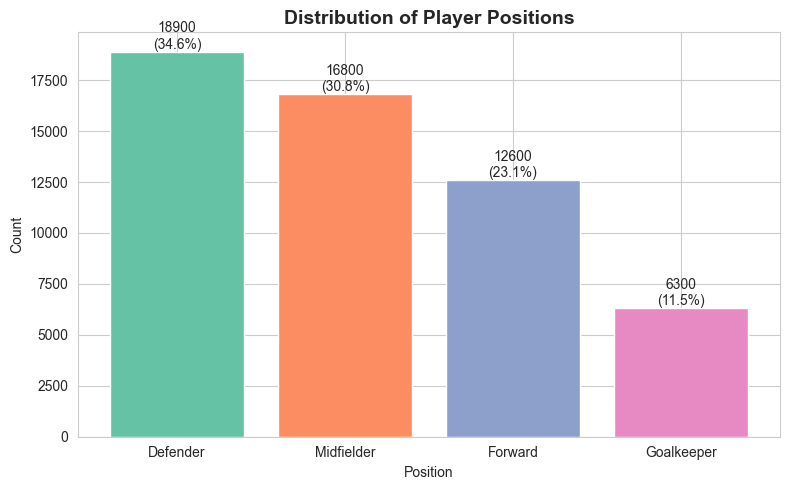

Observation: The dataset is imbalanced — Defenders are the most represented (34.6%), while Goalkeepers are the least (11.5%). This means we should use stratified splitting and weighted metrics for fair evaluation.


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
position_counts = df['position'].value_counts()
bars = ax.bar(position_counts.index, position_counts.values,
              color=sns.color_palette('Set2', len(position_counts)))
ax.set_title('Distribution of Player Positions', fontsize=14, fontweight='bold')
ax.set_xlabel('Position')
ax.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}\n({height/len(df)*100:.1f}%)',
           ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', bbox_inches='tight')
plt.show()
print("Observation: The dataset is imbalanced — Defenders are the most represented (34.6%), "
      "while Goalkeepers are the least (11.5%). This means we should use stratified splitting "
      "and weighted metrics for fair evaluation.")


<h4>2.2 Feature Distributions</h4>

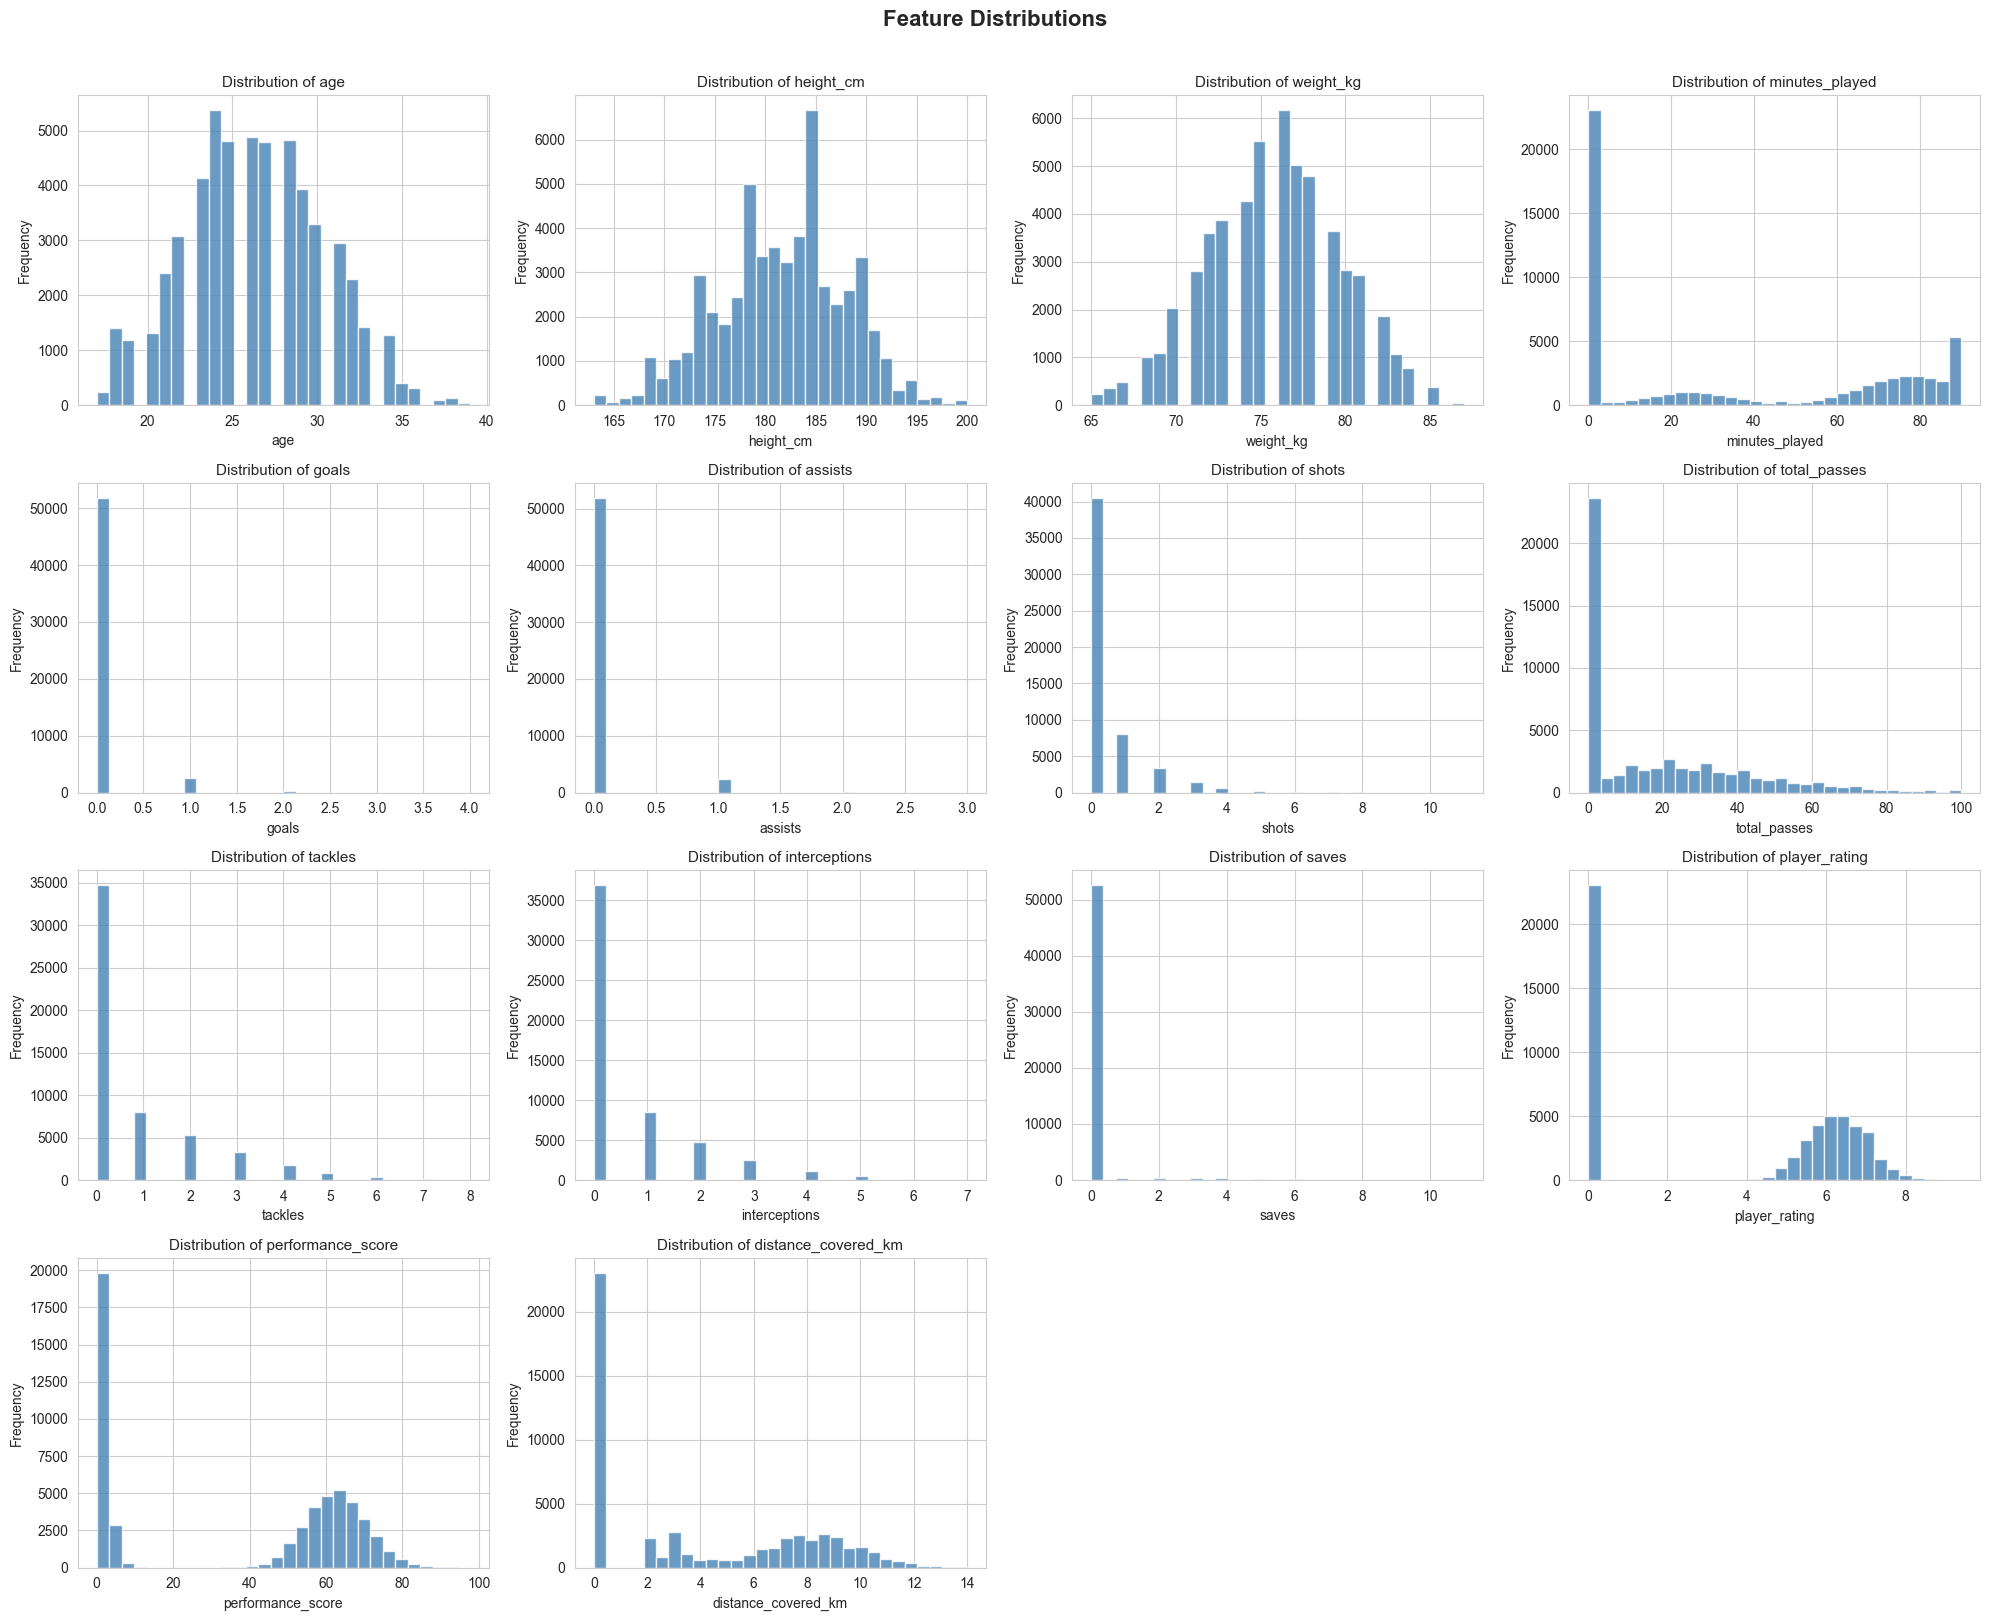

Observation: Most counting stats (goals, assists, shots, saves) are heavily right-skewed with most values at 0, which is expected in football — most players don't score or attempt many shots in a given match. Physical attributes (height, weight, age) show more normal-like distributions.


In [22]:
key_features = ['age', 'height_cm', 'weight_kg', 'minutes_played', 'goals',
                'assists', 'shots', 'passes' if 'passes' in df.columns else 'total_passes',
                'tackles', 'interceptions', 'saves', 'player_rating',
                'performance_score', 'distance_covered_km']

dist_features = ['age', 'height_cm', 'weight_kg', 'minutes_played', 'goals',
                 'assists', 'shots', 'total_passes', 'tackles', 'interceptions',
                 'saves', 'player_rating', 'performance_score', 'distance_covered_km']
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(dist_features):
    if col in df.columns:
        axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_title(f'Distribution of {col}', fontsize=11)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
for j in range(len(dist_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight')
plt.show()
print("Observation: Most counting stats (goals, assists, shots, saves) are heavily right-skewed "
      "with most values at 0, which is expected in football — most players don't score or attempt "
      "many shots in a given match. Physical attributes (height, weight, age) show more "
      "normal-like distributions.")

<h4>2.3 Correlation Heatmap</h4>

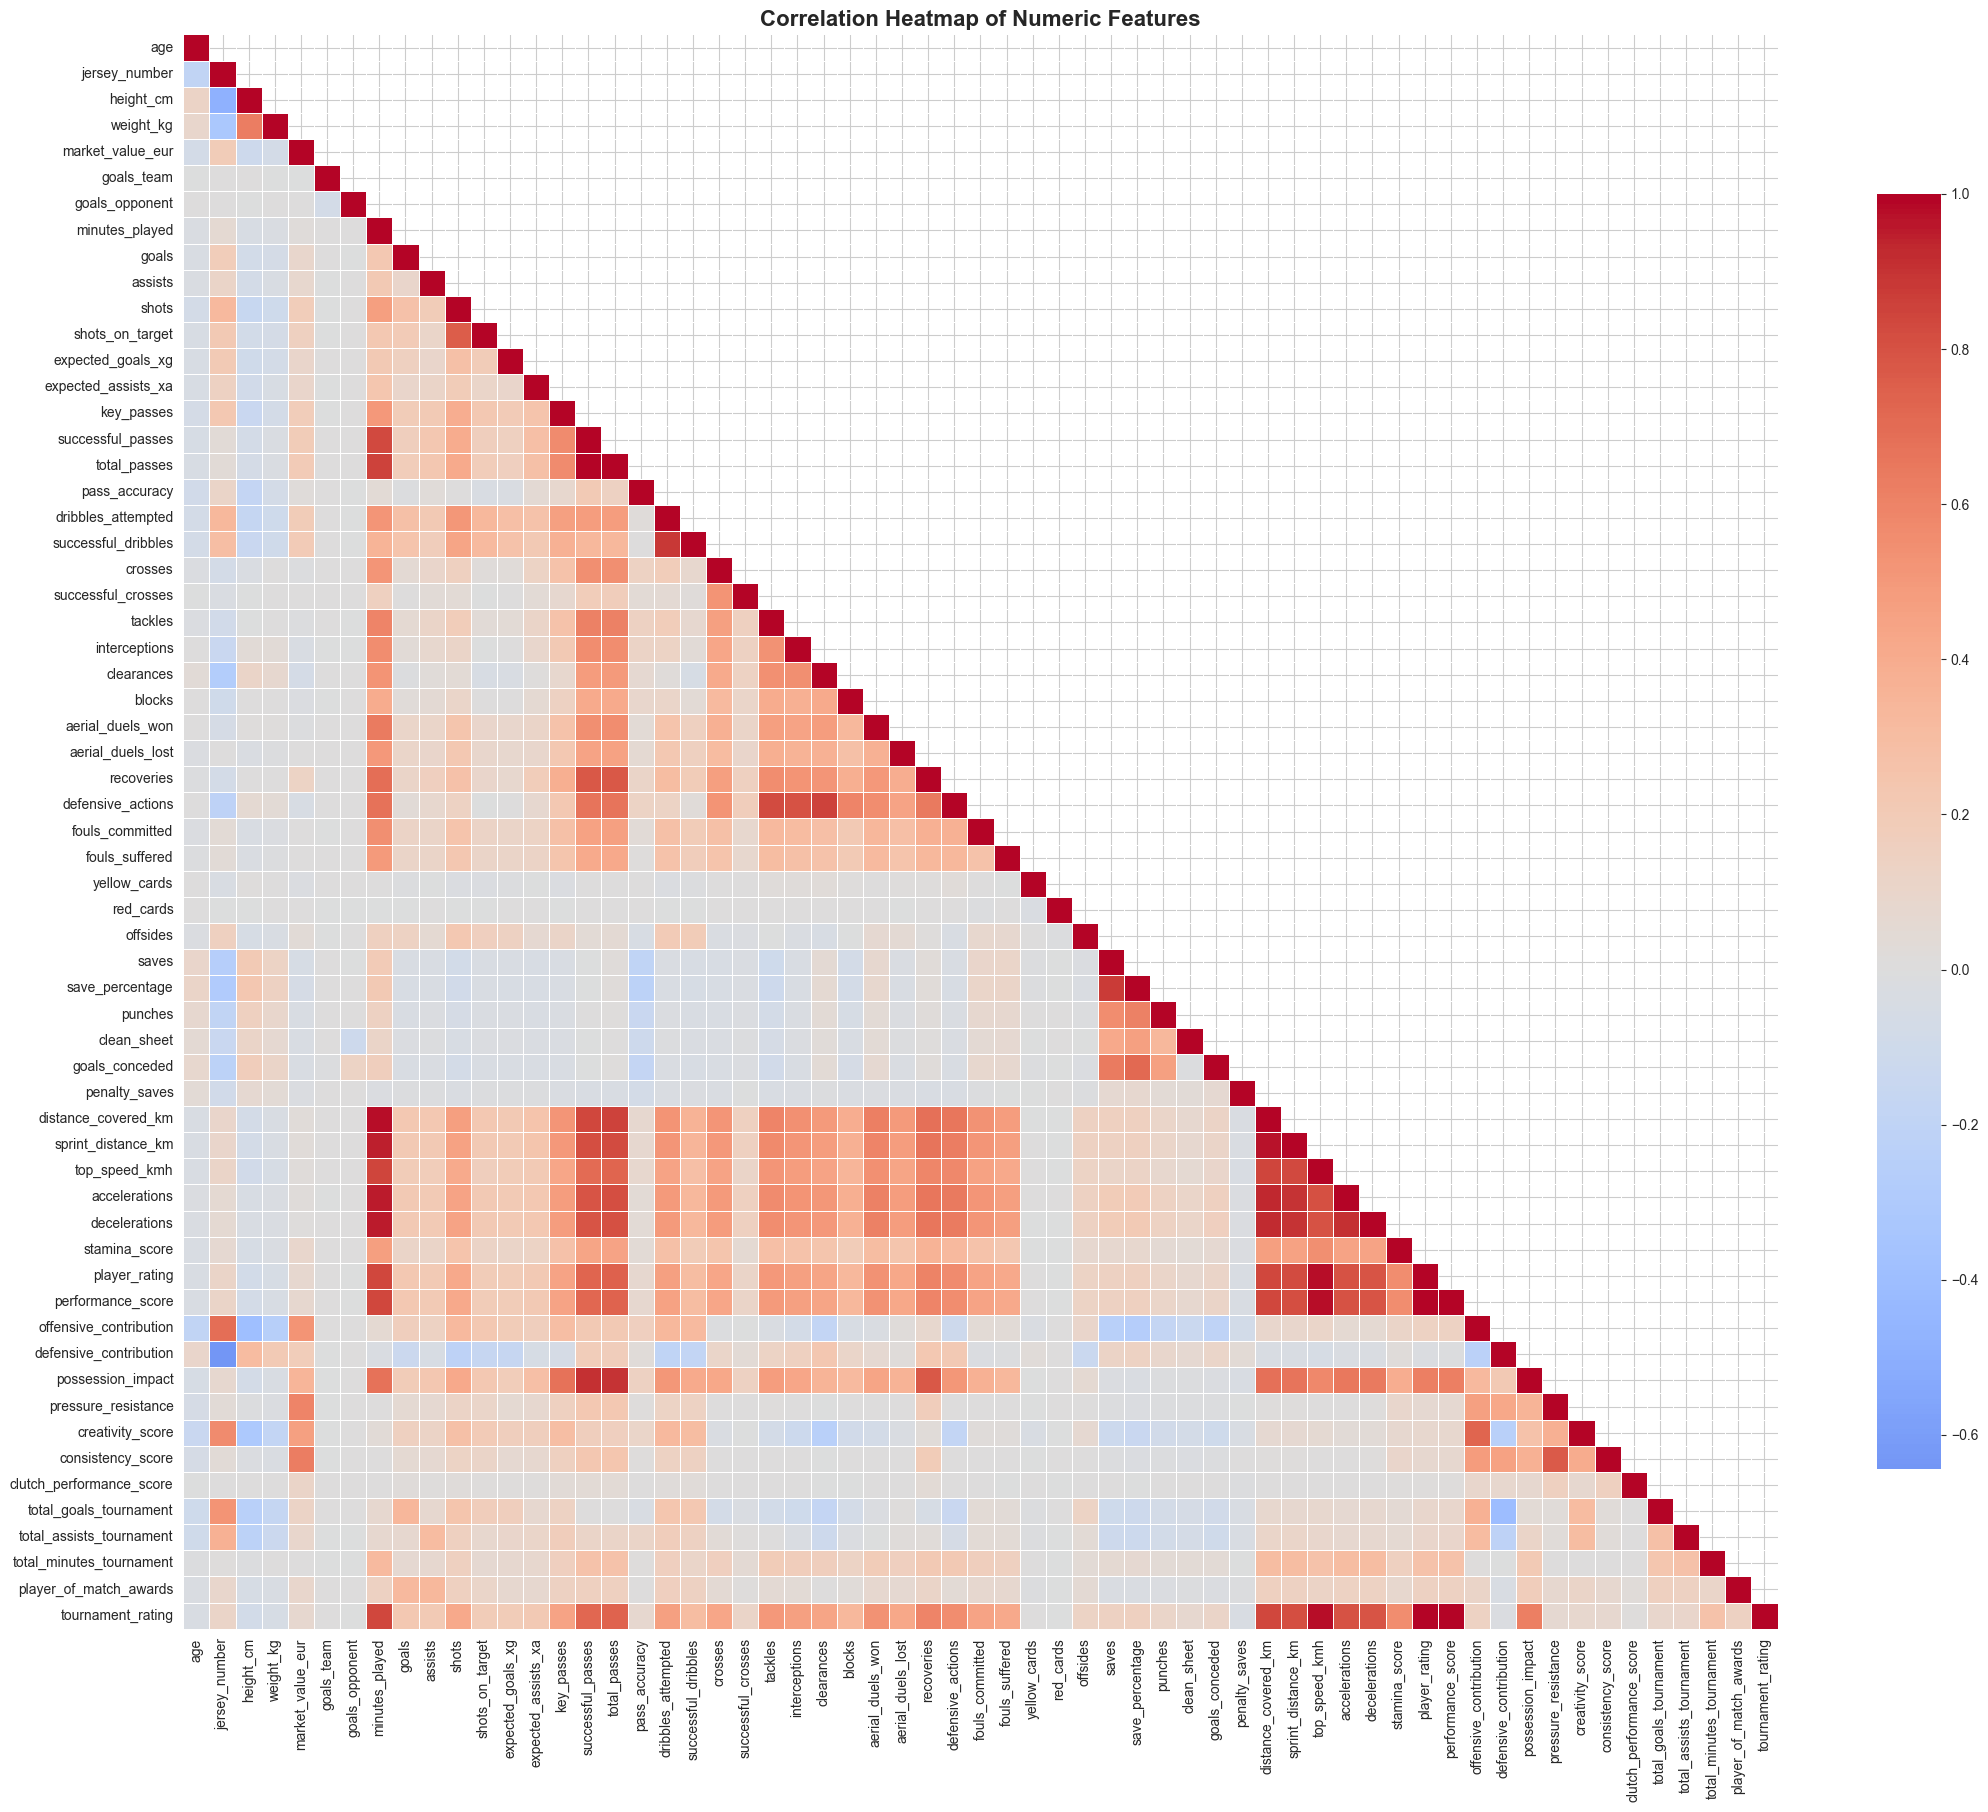

Top 15 absolute correlations:
player_rating        tournament_rating      0.997337
tournament_rating    player_rating          0.997337
player_rating        performance_score      0.996610
performance_score    player_rating          0.996610
total_passes         successful_passes      0.994782
successful_passes    total_passes           0.994782
tournament_rating    performance_score      0.993943
performance_score    tournament_rating      0.993943
player_rating        top_speed_kmh          0.979422
top_speed_kmh        player_rating          0.979422
distance_covered_km  minutes_played         0.977282
minutes_played       distance_covered_km    0.977282
top_speed_kmh        tournament_rating      0.976900
tournament_rating    top_speed_kmh          0.976900
performance_score    top_speed_kmh          0.975388
dtype: float64


In [24]:
# Select numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Show top correlations
print("Top 15 absolute correlations:")
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print(corr_pairs.head(15))


<h4>2.4 Feature-Target Relationships</h4>

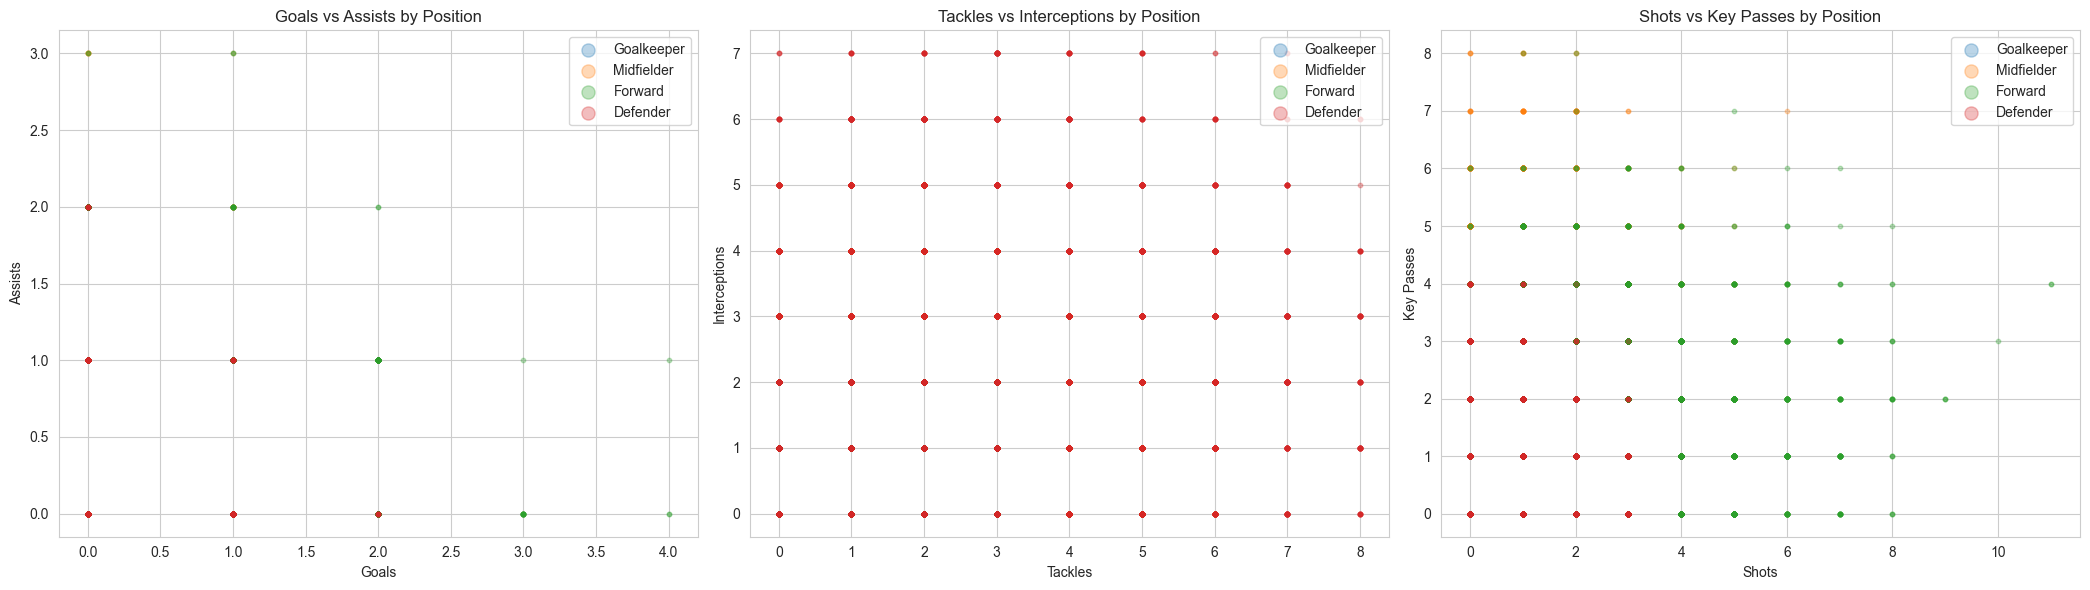

Observation: The scatter plots reveal clear position-based patterns:
- Forwards cluster in high-goals/high-shots regions
- Defenders cluster in high-tackles/high-interceptions regions
- Goalkeepers are concentrated at 0 for outfield stats (goals, assists, tackles)
- Midfielders are spread across moderate values of both offensive and defensive stats


In [25]:
# Scatter plots showing feature-target relationships
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Plot 1: Goals vs Assists coloured by position
for pos in df['position'].unique():
    subset = df[df['position'] == pos]
    axes[0].scatter(subset['goals'], subset['assists'], label=pos, alpha=0.3, s=10)
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Assists')
axes[0].set_title('Goals vs Assists by Position')
axes[0].legend(markerscale=3)

# Plot 2: Tackles vs Interceptions coloured by position
for pos in df['position'].unique():
    subset = df[df['position'] == pos]
    axes[1].scatter(subset['tackles'], subset['interceptions'], label=pos, alpha=0.3, s=10)
axes[1].set_xlabel('Tackles')
axes[1].set_ylabel('Interceptions')
axes[1].set_title('Tackles vs Interceptions by Position')
axes[1].legend(markerscale=3)

# Plot 3: Shots vs Key Passes coloured by position
for pos in df['position'].unique():
    subset = df[df['position'] == pos]
    axes[2].scatter(subset['shots'], subset['key_passes'], label=pos, alpha=0.3, s=10)
axes[2].set_xlabel('Shots')
axes[2].set_ylabel('Key Passes')
axes[2].set_title('Shots vs Key Passes by Position')
axes[2].legend(markerscale=3)

plt.tight_layout()
plt.savefig('eda_scatter_feature_target.png', bbox_inches='tight')
plt.show()
print("Observation: The scatter plots reveal clear position-based patterns:")
print("- Forwards cluster in high-goals/high-shots regions")
print("- Defenders cluster in high-tackles/high-interceptions regions")
print("- Goalkeepers are concentrated at 0 for outfield stats (goals, assists, tackles)")
print("- Midfielders are spread across moderate values of both offensive and defensive stats")

<h4>2.5 Position-wise Feature Comparision</h4>

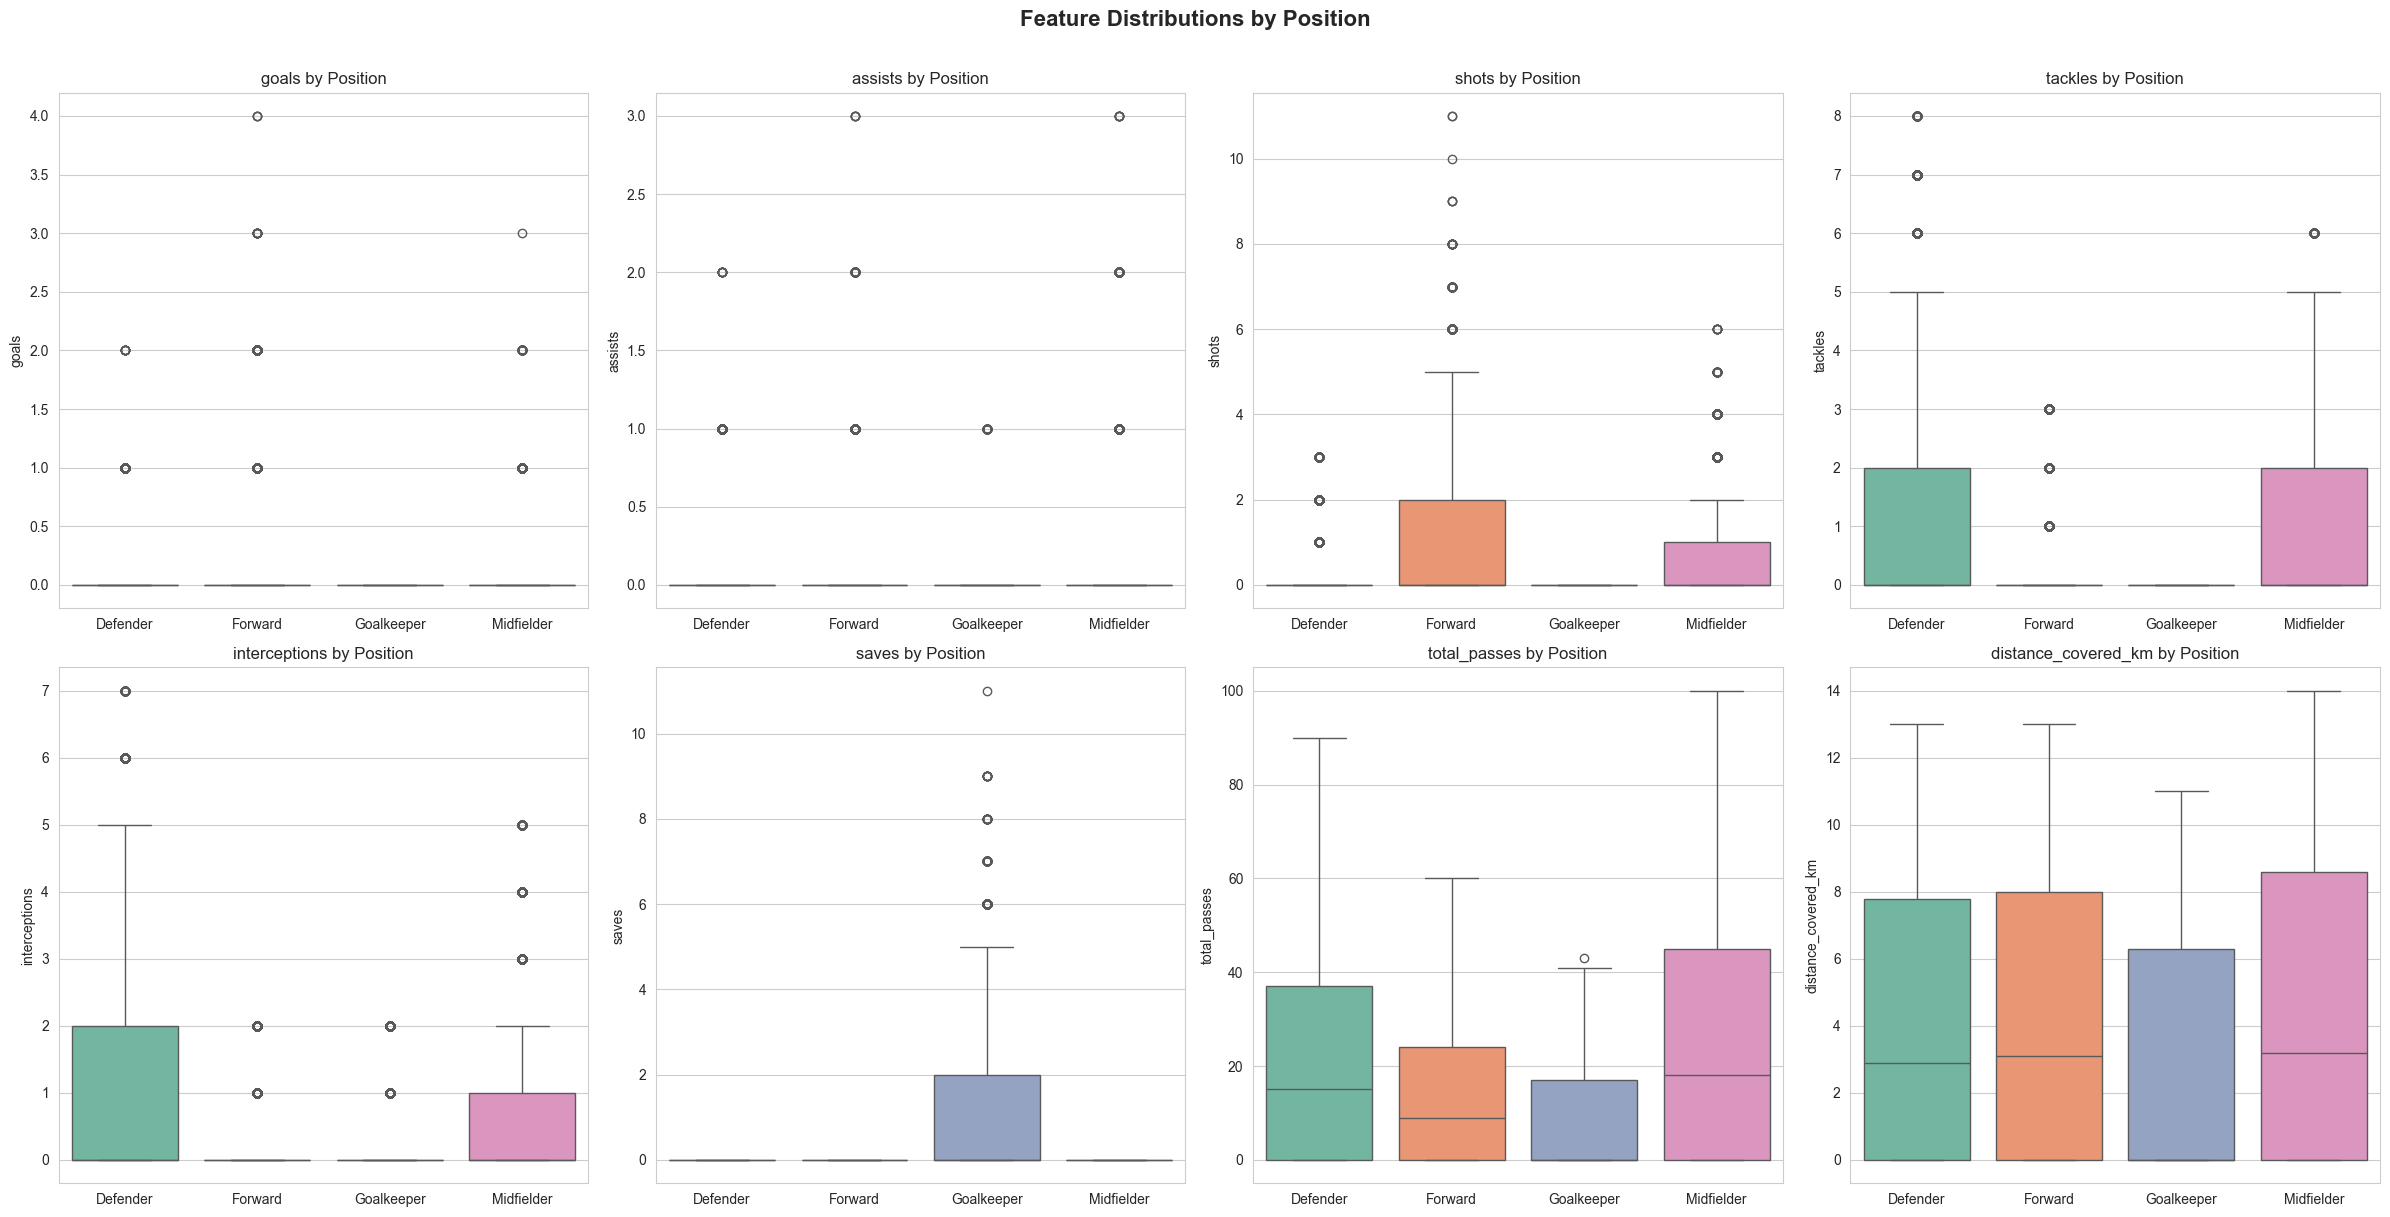

Observation: Box plots confirm distinct positional profiles — Goalkeepers dominate saves, Forwards lead in goals/shots, Defenders lead in tackles/clearances, and Midfielders show balanced contributions across categories.


In [26]:
# Box plots showing how key features vary across positions
box_features = ['goals', 'assists', 'shots', 'tackles', 'interceptions',
               'saves', 'total_passes', 'distance_covered_km']

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()
for i, col in enumerate(box_features):
    sns.boxplot(data=df, x='position', y=col, ax=axes[i],
                palette='Set2', order=sorted(df['position'].unique()))
    axes[i].set_title(f'{col} by Position', fontsize=12)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions by Position', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots_by_position.png', bbox_inches='tight')
plt.show()
print("Observation: Box plots confirm distinct positional profiles — Goalkeepers dominate saves, "
      "Forwards lead in goals/shots, Defenders lead in tackles/clearances, and Midfielders "
      "show balanced contributions across categories.")


<h3>Section B - Data Preprocessing & Feature Engineering</h3>
<h4>Data Cleaning:</h4>

In [47]:
# 1. Drop Unnecessary Columns
drop_cols = [
    'player_id', 'player_name', 'match_id', 'match_date', 'jersey_number',
    'nationality', 'team', 'club_name', 'opponent_team', 'stadium', 'city',
    'match_result', 'tournament_stage'
]
df_clean = df.drop(columns=drop_cols).copy()
print("Original shape:", df.shape)
print("After dropping columns:", df_clean.shape)

# 2. Handle Missing Vales
print("\nMissing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
print("Total missing values:", df_clean.isnull().sum().sum())

# 3. Remove Duplicates
duplicates = df_clean.duplicated().sum()
print("\nDuplicates found:", duplicates)
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

# 4. Detect and Cap Outliers Using IQR
outlier_cols = [
    col for col in df_clean.select_dtypes(include='number').columns
    if col not in ['position', 'preferred_foot']
]
outlier_report = []
for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report.append([
        col, Q1, Q3, IQR, lower, upper, outliers
    ])
    # Winsorization or Cappinng
    df_clean[col] = df_clean[col].clip(lower, upper)

# 5. Outlier Summary
outlier_df = pd.DataFrame(
    outlier_report,
    columns=['Column', 'Q1', 'Q3', 'IQR', 'Lower', 'Upper', 'Outliers']
)
outlier_df['Outlier %'] = (
    outlier_df['Outliers'] / len(df_clean) * 100
).round(2)
print("\nOutlier Summary:")
print(outlier_df.sort_values('Outlier %', ascending=False).head(15))


print("\nFinal dataset shape:", df_clean.shape)
print("Data cleaning completed successfully.")

Original shape: (54600, 75)
After dropping columns: (54600, 62)

Missing values:
Series([], dtype: int64)
Total missing values: 0

Duplicates found: 0
Shape after removing duplicates: (54600, 62)

Outlier Summary:
                    Column         Q1          Q3         IQR       Lower  \
30          fouls_suffered        0.0         0.0         0.0         0.0   
12     expected_assists_xa        0.0         0.0         0.0         0.0   
11       expected_goals_xg        0.0         0.0         0.0         0.0   
24                  blocks        0.0         0.0         0.0         0.0   
23              clearances        0.0         1.0         1.0        -1.5   
18     successful_dribbles        0.0         0.0         0.0         0.0   
21                 tackles        0.0         1.0         1.0        -1.5   
31            yellow_cards        0.0         0.0         0.0         0.0   
3         market_value_eur  4444778.0  23420128.0  18975350.0 -24018247.0   
25        aerial

<h4>Encoding:</h4>

In [48]:
# Encode the target variable (position)
le_target = LabelEncoder()
df_clean['position'] = le_target.fit_transform(df_clean['position'])

# Encode preferred_foot (Right or Left)
le_foot = LabelEncoder()
df_clean['preferred_foot'] = le_foot.fit_transform(df_clean['preferred_foot'])

# Print mappings for reference
print("Position:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
print("Preferred foot:", dict(zip(le_foot.classes_, le_foot.transform(le_foot.classes_))))


Position: {'Defender': np.int64(0), 'Forward': np.int64(1), 'Goalkeeper': np.int64(2), 'Midfielder': np.int64(3)}
Preferred foot: {'Left': np.int64(0), 'Right': np.int64(1)}


<h4>Feature Engineering:</h4>

In [50]:
#Feature 1: goal_conversion_rate
# Efficiency of converting shots into goals
df_clean['goal_conversion_rate'] = np.where(
    df_clean['shots'] > 0,
    df_clean['goals'] / df_clean['shots'],
    0.0
)

#Feature 2: aerial_duel_win_rate
# Dominance in aerial duels
total_aerial = df_clean['aerial_duels_won'] + df_clean['aerial_duels_lost']
df_clean['aerial_duel_win_rate'] = np.where(
    total_aerial > 0,
    df_clean['aerial_duels_won'] / total_aerial,
    0.0
)

print("Engineered features added: goal_conversion_rate, aerial_duel_win_rate")


Engineered features added: goal_conversion_rate, aerial_duel_win_rate


<h4>Train-Test Split & Scaling:</h4>

In [57]:
X = df_clean.drop(columns=['position'])
y = df_clean['position']
# 80:20 Split for Training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
X.shape

(54600, 63)

In [60]:
X_train.shape

(43680, 63)